In [20]:
import numpy as np

In [21]:
y = np.random.randint(100)
print(y)

97


In [ ]:
m = [1,10,1000,1000,10000]
models = []
for i in range(m):
    models.append(np.array([np.random.randint(100)]))

In [23]:
def MSE(pred_vector,ground_truth):
    err = 0
    n = len(pred_vector)
    for i in range(n):
        err += ((pred_vector[i]-ground_truth)**2)/n
    return err

In [24]:
lowest_err = float("inf")
best_model = 0
for i in range(len(models)):
    error = MSE(models[i],y)
    print(error)
    if error < lowest_err:
        best_model = i
        lowest_err = error

print(f"Best model is {best_model}, with error of {lowest_err}")

441.0
529.0
900.0
1369.0
25.0
3844.0
7225.0
5929.0
4489.0
8836.0
Best model is 4, with error of 25.0


In [31]:
new_y = np.random.randint(100)
print(new_y)

62


In [32]:
test_MSE = MSE(models[4],new_y)

In [33]:
print(test_MSE)

900.0


Best model is 0, with error of 2.203405324523461
Best model is 8, with error of 2.555975753479803
Best model is 79, with error of 1.960050947372335
Best model is 642, with error of 1.8299415554861795
Best model is 4553, with error of 1.4769435012450547
[0.0, 0.10729830131446737, 0.15174271293851463, 0.1858461094424919, 0.21459660262893474]
[np.float64(0.6301159510538628), np.float64(0.03197011224187385), np.float64(0.28084537647955043), np.float64(0.7783161065887039), np.float64(1.499913749559468)]


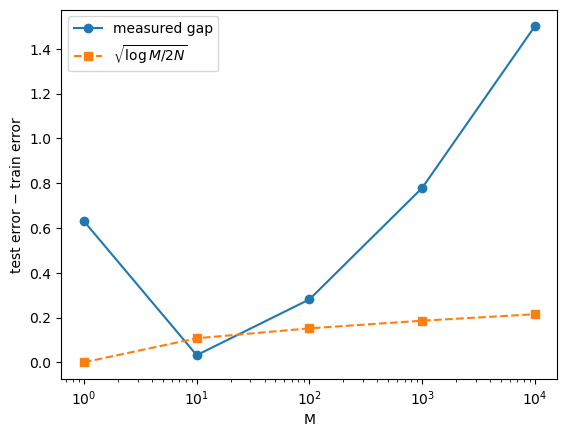

In [50]:
import numpy as np
import math
from matplotlib import pyplot as plt

def MSE(pred_vector, ground_truth_vector):
    n = len(pred_vector)
    return sum((pred_vector[i] - ground_truth_vector[i])**2 for i in range(n)) / n

m = [10**i for i in range(5)]
overlay_values = []
MSE_gap_vals = []
for m_value in m:
    y_train = np.random.uniform(1, 5, size=100)
    models = [np.random.uniform(1, 5, size=100) for _ in range(m_value)]

    lowest_err = float("inf")
    best_model = 0
    for i in range(len(models)):
        error = MSE(models[i],y_train)
        # print(error)
        if error < lowest_err:
            best_model = i
            lowest_err = error

    print(f"Best model is {best_model}, with error of {lowest_err}")

    new_y = np.random.uniform(1, 5, size=100)
    # print(f"Test y: {new_y}")
    test_MSE = MSE(models[best_model],new_y)
    MSE_gap_vals.append(test_MSE - lowest_err)
    overlay_values.append((math.log(m_value)/200)**0.5)

print(overlay_values)
print(MSE_gap_vals)


plt.semilogx(m, MSE_gap_vals, "o-", label="measured gap")
plt.semilogx(m, overlay_values, "s--", label=r"$\sqrt{\log M / 2N}$")
plt.xlabel("M")
plt.ylabel("test error − train error")
plt.legend()

plt.show()

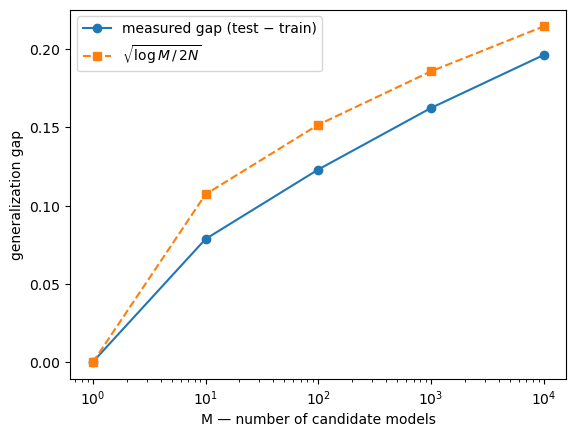

In [36]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

N, REPS = 100, 200
Ms = [1, 10, 100, 1000, 10000]

gaps = []
for M in Ms:
    rep = []
    for _ in range(REPS):
        y_train = rng.integers(0, 2, size=N)        # pure noise, no signal
        y_test  = rng.integers(0, 2, size=N)        # fresh labels
        models  = rng.integers(0, 2, size=(M, N))   # M candidate predictors

        train_err = (models != y_train).mean(axis=1)
        best = train_err.argmin()
        test_err = (models[best] != y_test).mean()

        rep.append(test_err - train_err[best])
    gaps.append(np.mean(rep))

overlay = [np.sqrt(np.log(M) / (2 * N)) for M in Ms]

plt.semilogx(Ms, gaps, "o-", label="measured gap (test − train)")
plt.semilogx(Ms, overlay, "s--", label=r"$\sqrt{\log M \,/\, 2N}$")
plt.xlabel("M — number of candidate models")
plt.ylabel("generalization gap")
plt.legend()
plt.show()